# Summary visualizations

This notebook loads the aggregated summary CSVs produced by `scripts/aggregate_cycle_outputs.py` and provides a few starter visualizations for exploration.

Place this notebook in the repository root and run the cells after the aggregator has produced files under `data/derived/cycle_analysis/summary/`.

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY_DIR = Path('data/derived/cycle_analysis/summary')
assert SUMMARY_DIR.exists(), 'Run scripts/aggregate_cycle_outputs.py first'

def load_if_exists(name):
    p = SUMMARY_DIR / name
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

summary_adjud = load_if_exists('summary_adjudication_by_cycle_session.csv')
summary_conf = load_if_exists('summary_adjudication_confidence_by_cycle_session.csv')
# Prefer PI-only evidence summary when present to avoid mixing fidelity rows into PI visualizations
summary_evidence = load_if_exists('summary_evidence_by_cycle_pionly.csv')
if summary_evidence.empty:
    # fallback to legacy combined summary for backward compatibility
    summary_evidence = load_if_exists('summary_evidence_by_cycle.csv')
summary_pi = load_if_exists('summary_pi_questions_by_cycle.csv')

print('Loaded:', { 'adjud': not summary_adjud.empty, 'conf': not summary_conf.empty, 'evidence': not summary_evidence.empty, 'pi': not summary_pi.empty })

Loaded: {'adjud': True, 'conf': True, 'evidence': True, 'pi': True}


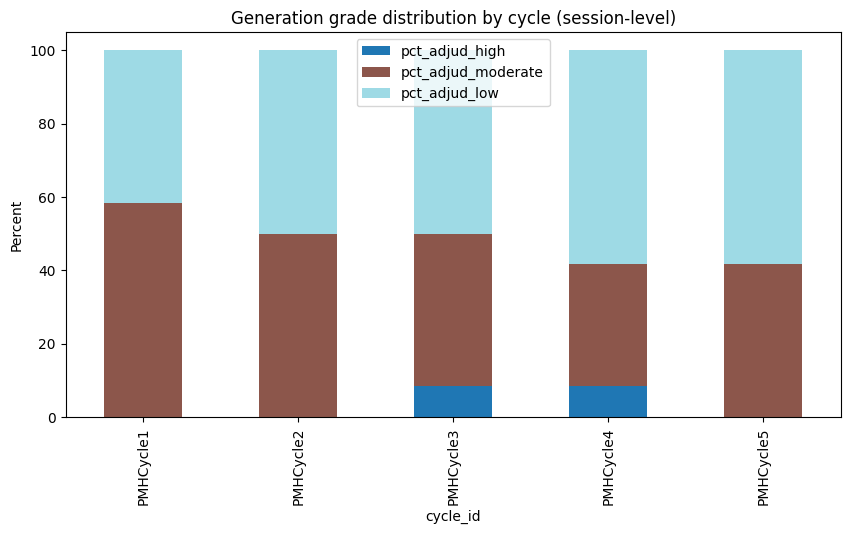

In [2]:
# Adjudication by cycle (generation grade)
if not summary_adjud.empty:
    df = summary_adjud.copy()
    df = df.sort_values('cycle_id')
    df_m = df.set_index('cycle_id')[['pct_adjud_high','pct_adjud_moderate','pct_adjud_low']]
    ax = df_m.plot(kind='bar', stacked=True, figsize=(10,5), colormap='tab20')
    ax.set_ylabel('Percent')
    ax.set_title('Generation grade distribution by cycle (session-level)')
    plt.show()
else:
    print('summary_adjudication_by_cycle_session.csv not found or empty')

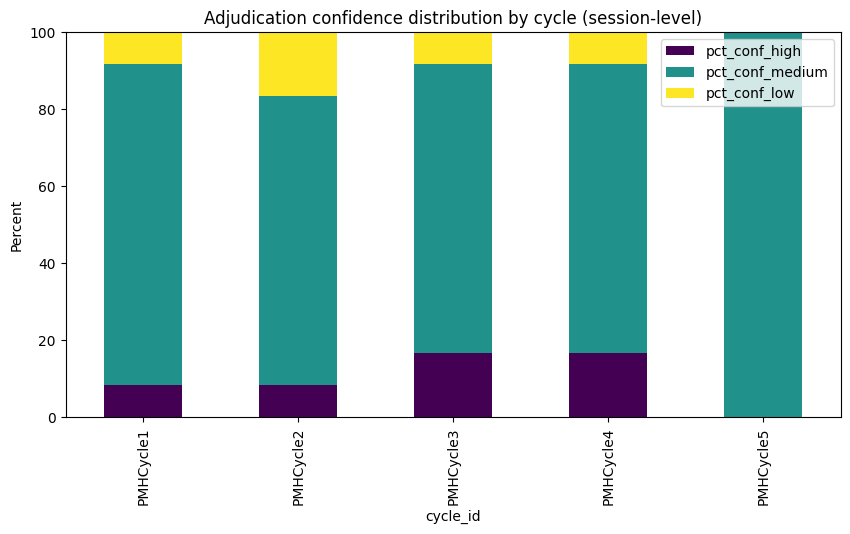

In [3]:
# Adjudication confidence by cycle
if not summary_conf.empty:
    df = summary_conf.copy()
    df = df.sort_values('cycle_id')
    df_m = df.set_index('cycle_id')[['pct_conf_high','pct_conf_medium','pct_conf_low']]
    ax = df_m.plot(kind='bar', stacked=True, figsize=(10,5), colormap='viridis')
    ax.set_ylabel('Percent')
    ax.set_title('Adjudication confidence distribution by cycle (session-level)')
    plt.show()
else:
    print('summary_adjudication_confidence_by_cycle_session.csv not found or empty')

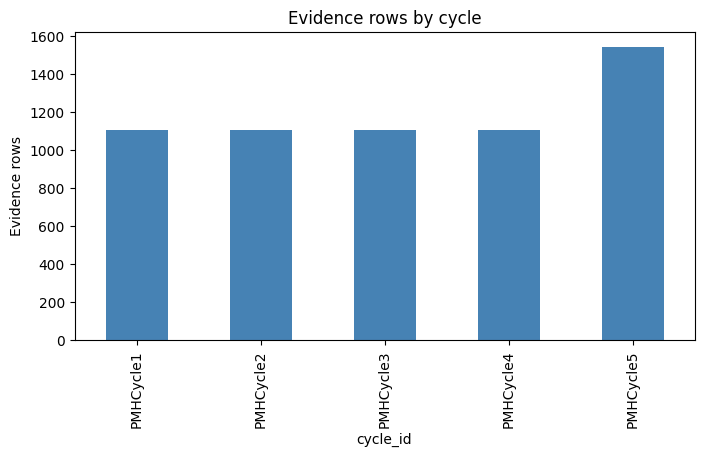

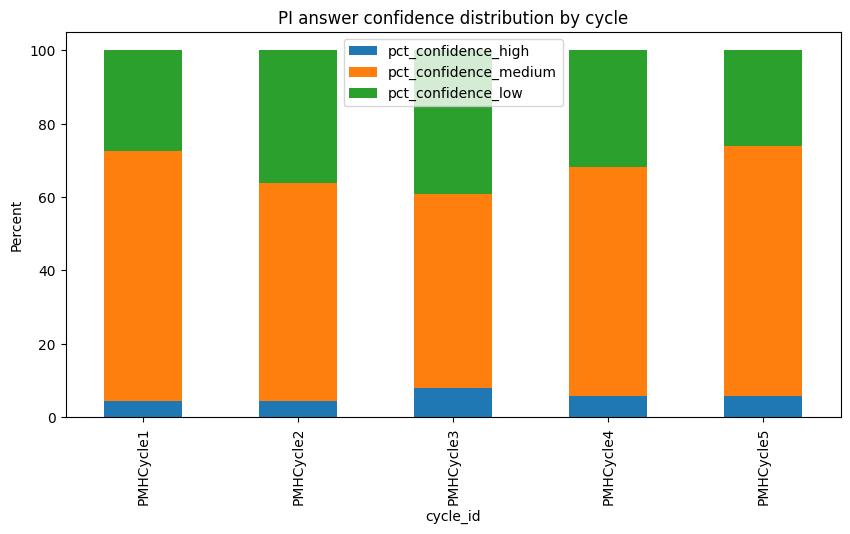

In [4]:
# Evidence and PI summaries
if not summary_evidence.empty:
    df = summary_evidence.copy()
    df = df.sort_values('cycle_id')
    ax = df.set_index('cycle_id')['evidence_rows'].plot(kind='bar', figsize=(8,4), color='steelblue')
    ax.set_ylabel('Evidence rows')
    ax.set_title('Evidence rows by cycle')
    plt.show()
else:
    print('summary_evidence_by_cycle.csv not found or empty')

if not summary_pi.empty:
    df = summary_pi.copy()
    df = df.sort_values('cycle_id')
    ax = df.set_index('cycle_id')[['pct_confidence_high','pct_confidence_medium','pct_confidence_low']].plot(kind='bar', stacked=True, figsize=(10,5))
    ax.set_ylabel('Percent')
    ax.set_title('PI answer confidence distribution by cycle')
    plt.show()
else:
    print('summary_pi_questions_by_cycle.csv not found or empty')

Loaded data/derived/cycle_analysis/summary/summary_session_fidelity_by_cycle.csv shape= (5, 11)


,cycle_id,manual_session_rows,mean_adherence_score,median_adherence_score,mean_manual_unit_coverage,mean_subsection_coverage,mean_evidence_density,mean_retrieved_evidence_count,pct_high_adherence,pct_moderate_adherence,pct_low_adherence
0,PMHCycle1,12,0.4931,0.4670,0.4775,0.5166,1.6599,40.0,16.67,83.33,0.00
1,PMHCycle2,12,0.4238,0.4050,0.4175,0.4332,1.6599,40.0,0.00,91.67,8.33
2,PMHCycle3,12,0.4860,0.4675,0.4653,0.5174,1.6599,40.0,8.33,91.67,0.00
3,PMHCycle4,12,0.4354,0.3950,0.4228,0.4545,1.6599,40.0,16.67,66.67,16.67
4,PMHCycle5,12,0.4618,0.4640,0.4417,0.4920,1.6599,40.0,0.00,100.00,0.00


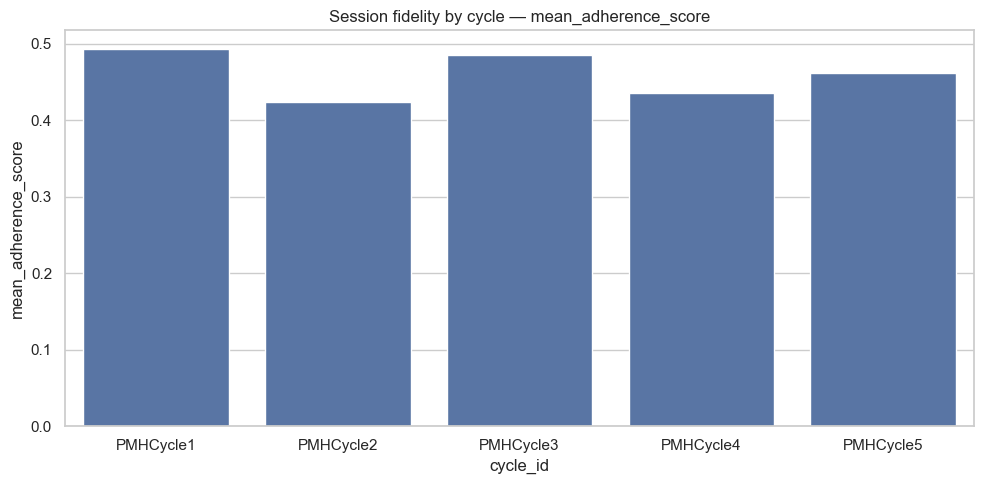

Loaded data/derived/cycle_analysis/summary/summary_session_fidelity_by_manual_session.csv shape= (12, 9)


,manual_session_num,manual_session_label,cycle_rows,mean_adherence_score,median_adherence_score,mean_manual_unit_coverage,mean_subsection_coverage,mean_evidence_density,mean_retrieved_evidence_count
0,1,Session 1,5,0.6376,0.648,0.5810,0.7228,1.905,40.0
1,2,Session 2,5,0.3918,0.373,0.4114,0.3626,1.143,40.0
2,3,Session 3,5,0.4028,0.399,0.3930,0.4182,1.429,40.0
3,4,Session 4,5,0.5038,0.504,0.4582,0.5712,1.667,40.0
4,5,Session 5,5,0.6048,0.615,0.6000,0.6126,1.739,40.0


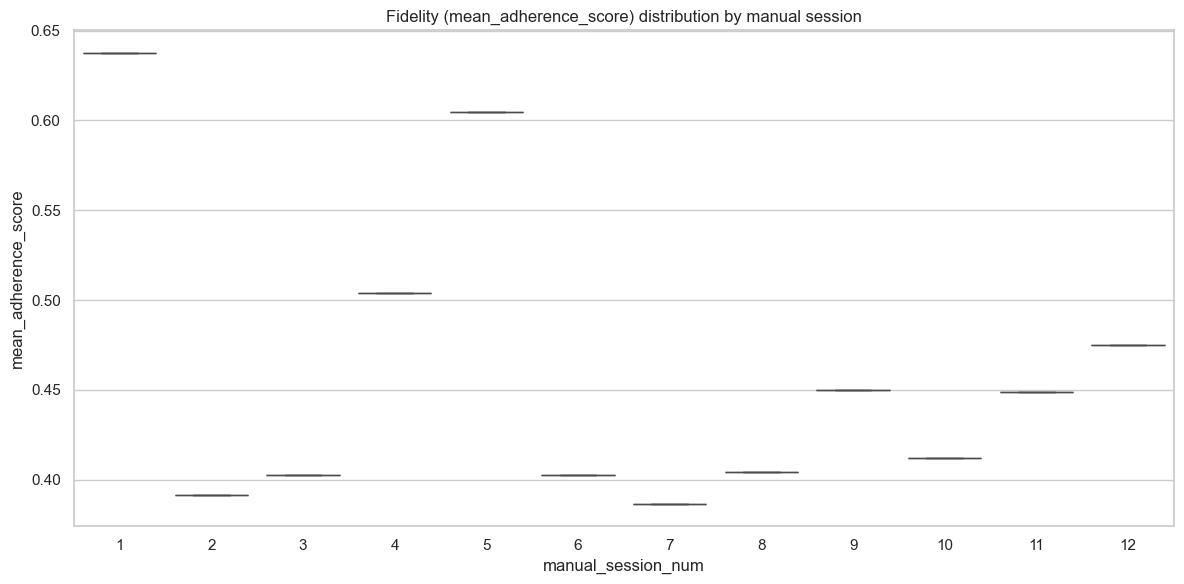

In [5]:
# Session fidelity by cycle
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY_DIR = Path('data/derived/cycle_analysis/summary')
path_cycle = SUMMARY_DIR / 'summary_session_fidelity_by_cycle.csv'
if not path_cycle.exists():
    print('Missing:', path_cycle)
else:
    df_cycle = pd.read_csv(path_cycle)
    print('Loaded', path_cycle, 'shape=', df_cycle.shape)
    display(df_cycle.head())

    # pick numeric columns to visualize
    num_cols = df_cycle.select_dtypes('number').columns.tolist()
    if not num_cols:
        print('No numeric columns found in', path_cycle)
    else:
        sns.set(style='whitegrid')
        plt.figure(figsize=(10,5))
        # prefer a column named like "adherence_score" or similar
        preferred = [c for c in num_cols if 'adher' in c.lower() or 'score' in c.lower()]
        ycol = preferred[0] if preferred else num_cols[0]
        if 'cycle_id' in df_cycle.columns:
            sns.barplot(data=df_cycle, x='cycle_id', y=ycol)
            plt.title(f'Session fidelity by cycle — {ycol}')
            plt.xlabel('cycle_id')
            plt.ylabel(ycol)
        else:
            # fall back to line plot of numeric columns
            df_cycle[num_cols].plot(kind='line', figsize=(10,5))
            plt.title('Session fidelity by cycle — numeric columns')
            plt.legend(loc='best')
        plt.tight_layout()
        plt.show()


# Session fidelity by manual session
path_manual = SUMMARY_DIR / 'summary_session_fidelity_by_manual_session.csv'
if not path_manual.exists():
    print('Missing:', path_manual)
else:
    df_manual = pd.read_csv(path_manual)
    print('Loaded', path_manual, 'shape=', df_manual.shape)
    display(df_manual.head())

    # Visualize distribution of a numeric fidelity metric by manual_session_num
    num_cols = df_manual.select_dtypes('number').columns.tolist()
    if not num_cols:
        print('No numeric columns found in', path_manual)
    else:
        sns.set(style='whitegrid')
        # choose likely fidelity column
        preferred = [c for c in num_cols if 'adher' in c.lower() or 'score' in c.lower()]
        valcol = preferred[0] if preferred else num_cols[0]
        plt.figure(figsize=(12,6))
        xcol = 'manual_session_num' if 'manual_session_num' in df_manual.columns else None
        if xcol is not None:
            sns.boxplot(data=df_manual, x=xcol, y=valcol)
            plt.xlabel(xcol)
        else:
            sns.boxplot(y=df_manual[valcol])
        plt.title(f'Fidelity ({valcol}) distribution by manual session')
        plt.ylabel(valcol)
        plt.tight_layout()
        plt.show()